# Домашнее задание №3. Линейная регрессия. Расширение признакового пространства. Регуляризация. Валидация

## Ф.И.О: Шарипов Артем Сергеевич

### Описание.

Домашнее задание состоит из 2-х частей:
  - теоретическая часть
  - практическая часть
    - реализация модуля линейной регрессии
    -  эксперименты

**На проверку требуется отправить zip архив, который будет содержать следующие файлы:**
  - модуль ``modules`` с реализованными классами
  - заполненный блокнот в формате ``.ipynb``
  - заполненный блокнот в формате ``.html`` **(в jupyter: File -> Save and Export Notebook As -> HTML -> ...)**

-------------------------

## Теоретическая часть. (4 points)

**№1.** (2 point) Найдите субдифференциалы для следующих функций:
- $f(x) = \max(0, 1 − ax), \ \ a \ — \ const$,  во всех точках

Из определения мы хотим найти все такие g, что f(y) ≥ f(x) + ⟨g, y - x⟩ ∀y для фиксированного x. Давайте договоримся, что a > 0. Возможно 3 случая:
1. f(x) = 1 - ax ⟺ 1 - ax > 0, то есть при x < 1/a. Тогда она дифференцируема, а значит ∂f = {-a}
2. f(x) = 0 ⟺ 1 - ax < 0, то есть при x > 1/a. Тогда она дифференцируема, а значит ∂f = {0}
3. f(x) = 1 - ax = 0 ⟹ x = 1/a. Тогда она не дифференцируема, так как это "точки излома" (левосторонний и правосторонние пределы не совпадут), а значит действуем по определению: max(0, 1 - ay) ≥ ⟨g, y - 1/a⟩ и:
*   Если 1 - ay < 0, то g <= 0;
*   Если 1 - ay > 0, то 1 - ay ≥ g (ya - 1) / a ⟹ g >= -a;

Итого g ∈ [-a, 0].

---

Итого получаем: ∂f = {-a, если x < 1/a; 0, если x > 1/a; [-a, 0], если x = 1/a}.

Аналогично нужно рассмотреть случай a < 0 и получим: ∂f = {a, если x > -1/a; 0, если x < -1/a; [0, a], если x = -1/a}.

А в случае a = 0 получим f(x) = 1 ⟹ ∂f = {0}.

- $f(x) = \sin x, \ x \in [0; \frac{3}{2} \pi]$

Я интерпретировал это как $\sin(x)$, заданный на отрезке (просто мало ли имелось ввиду исследовать на отрезке). Заметим, что $f(x)$ дифференцируема на интервале $(0, \frac{3\pi}{2})$ (концевые точки рассмотрим позже), а значит
$$\partial f (x) \in \{ \emptyset, \nabla{f}\}.$$

Проверим $\nabla{f} = \cos{x}$. На $(0, \pi)$ функция вогнута, поэтому это будет $\emptyset$, а на $(\pi, 3\pi / 2)$ выпукла, поэтому $\cos{x}$. Остается проверить лишь $x \in \{0, \pi, 3\pi / 2\}$. Для этого можно использовать определение:
$$\forall x \in \mathbb{R} \hookrightarrow f(x) \geq 0 + g (x - 0);$$
$$\forall x \in \mathbb{R} \hookrightarrow f(x) \geq 0 + g (x - \pi);$$
$$\forall x \in \mathbb{R} \hookrightarrow f(x) \geq -1 + g (x - 3\pi / 2).$$

Распишем подробно случай $x_0 = \pi$:

если $x = 0$, то $g \geq 0$; если $x = 3\pi / 2$, то $g \leq -2/\pi$. То есть $\nexists g$. Остальное расписывать смысла не вижу.


Итого:

$$\partial f \in \{ (-\infty, -2 / (3\pi)], x = 0; \emptyset, x \in (0, \pi]; \cos{x}, x \in (\pi, 3\pi / 2); [0, +\infty), x = 3\pi / 2\}.$$


**№2.** (2 point) Рассмотрим задачу линейной регрессии с регуляризацией:

$$L(w) = \| Xw - y\|_2^2 + \lambda R(w)$$

И попробуем разобраться, в каких случаях возникает случай вырожденного (нулевого решения) для LASSO и Ridge регрессии.

- Покажите, что если оптимальное решение $w^*$ функционала $L(w) = \| Xw - y\|_2^2 + \lambda \|w\|_1$ равно нулю, то выполняется неравенство $\| 2 X^T y \|_{\infty} \le \lambda$.

Вычислим градиент первого слагаемого (пусть оно f(w)):

$$\text{grad} f(w) = 2X^{T} (X w - y).$$

Вычислим градиент второго слагаемого (пусть оно h(w)):

$$\text{grad} h(w) = λ \frac{w}{\| w \|_1}.$$

То есть оно не дифференцируемо в нуле. Придется искать субдифференциал:(
  
От f(w) он очевиден, так как она дифференцируема всюду, соответственно $$∂f(w) = \{\text{grad} f(w)\}$$

В свою очередь для $\| w \|_1$ ↪

$$∂\|w\|_1 \in \{ v: v_i ∈ [-1, 1], при\  w_i = 0; v_i = \text{sign}(w_i), иначе \}.$$

Нам надо, чтобы $0 \in ∂L(w) = \{2X^{T} (X w - y)\} + λ ∂\|w\|_1$, притом при $w^* = 0$. Подставим это:

$∂L(w) = \{ -2X^{T}y\} + λ ∂\|0\|_1$. Правая часть есть, в свою очередь исходя из найденного ранее, всевозможные вектора с каждой компонентой в [-1, 1], то есть $\{v: v_i ∈ [-1, 1]\} \ ∀i$. И давайте условимся такие вектора записывать как $\mathbb{V}$ (читать как "В-красивое") для удобства. Тогда наше "надо" перепишется как:
$$0 \in \{ -2X^{T} y\} + λ\mathbb{V},$$ где $\mathbb{V}$ в смысле выше ⟹ $2X^{T} y ∈ λ\mathbb{V}$ ⟹ Перейдем к по-компонентной записи:

$2X^T y_i \in [-λ, λ] \ \forall i ⟺ |2 X^T y_i| ≤ λ$, что и есть "бесконечность-норма". Итого:

$$\|2X^T y\|_∞ ≤ λ,$$ Ч.т.д.

- Покажите, что для функционала $L(w) = \| Xw - y\|_2^2 + \lambda \| w \|_2^2$ при $X^Ty \neq 0$ не существует $\lambda$ такого, что оптимальное решение $w^*$ обращается в нуль.

Собственно, от предыдущего пункта отличается только правая часть суммы. Посмотрим на нее (обозначив за h):
$$\text{grad} h(w) = 2 \lambda w$$
То есть она дифференцируема всюду и мы имеем дело с обычным градиентом L (это победа). Итак,
$$\text{grad} L = 2X^T (X w - y) + 2 \lambda w,$$
оптимальное решение значит, что $\text{grad} L = 0 \Longrightarrow$
$$2X^T (Xw - y) + 2 \lambda w = 0 \Longleftrightarrow (X^T X + \lambda E) w = X^T y,$$
то есть если бы такое было в $w^* = 0$, то вне зависимости от значения $\lambda$ было бы $X^T y = 0$, а это противоречит условию.

Итого при $X^T y \neq 0$ не существует $\lambda$ такого, что оптимальное решение $w^*$ обращается в нуль, Ч.т.д.

------------------------

## Практическая часть. (16 points)

Данная часть задания направлена на ознакомление с линейными моделями и градиентными методами обучения. В задании необходимо:
1. Написать на языке Python собственную реализацию модели линейной регрессии с произвольной функцией потерь и реализацию функции и градиента функции потерь для линейной регрессии. Реализации можно частично проверить через юнит-тесты (запускаются командой ``pytest tests.py``).
2. Провести описанные ниже эксперименты с модельными данными и приложенным датасетом.
3. Написать отчёт о проделанной работе (в формате jupyter notebook).

### Реализация алгоритмов. (3 points)

Везде под выборкой объектов будем понимать ``numpy.ndarray`` размера $N \times D$ или разреженную матрицу ``scipy.sparse.csr_matrix`` того же размера, под ответами для объектов выборки будем понимать ``numpy.ndarray`` размера $N$ , где $N$ — количество объектов в выборке, $D$ — размер признакового пространства. Подрузамевается, что первый столбец выборки объектов соответствует признаку для смещения и равен единице.

- **``losses.py``** (1 point)
  - класс в этом модуле задаёт конкретную функцию потерь, которую можно использовать для обучения линейной модели. Обратите внимание на то, что подсчёт всех функций может быть полностью векторизован (т.е. их можно реализовать без циклов). Предложенная в задании функция потерь должна поддерживать использование $l2$-регуляризации. Обратите внимание, что признак для смещения **не** должен учитываться в регуляризаторе.
  - Класс должен поддерживать как плотные матрицы (``numpy.ndarray``), так и разреженные матрицы (``scipy.sparse.csr_matrix``). Класс ``LinearLoss`` наследуется от абстрактного класса BaseLoss и реализует два метода: ``func`` и ``grad``.
    - ``func(self, X, y, w)`` — вычисление значения функции потерь на матрице признаков $X$, векторе ответов $y$ с вектором весов $w$.
    - ``grad(self, X, y, w)`` — вычисление значения градиента функции потерь на матрице признаков $X$, векторе ответов $y$ с вектором весов $w$.
  - У обоих методов одинаковые аргменты:
     - $X$ - выборка объектов
     - $y$ - вектор ответов
     - $w$ - вектор коэффициентов модели ``numpy.ndarray``.

В данном задании предлагается реализовать следующую функцию потерь:

$$L(X,y,w, \lambda) = \frac{1}{N} \| Xw - y \|_2^2 + \lambda \|w\|_2^2$$

- **``linear_model.py``** (2 points)
  - модуль с реализацией линейной модели, поддерживающей обучение через полный и стохастический градиентные спуски. Линейная модель должна задаваться в классе LinearModel. Параметр $\eta_k > 0$ — темп обучения (learning rate) для градиентного спуска, где $k$ — номер эпохи, должен параметризовываться формулой: $\eta_k = \dfrac{\alpha}{k^{\beta}}, \ где \ \ \alpha, \beta \ — \ \ заданные \ константы, \ \ k \ — \ \ номер \ итерации$

  - Описание методов класса:
    - ``__init__`` — конструктор (инициализатор) класса с параметрами:
      - ``loss_function`` — функция потерь, заданная классом, наследованным от ``BaseLoss``
      - ``batch_size`` — размер подвыборки, по которой считается градиент, если ``None``, то необходимо использовать полный градиент
      - ``step_alpha`` — параметр выбора шага градиентного спуска
      - ``step_beta`` — параметр выбора шага градиентного спуска
      - ``tolerance`` — точность, по достижении которой, необходимо прекратить оптимизацию.
        - **В данном случае в качестве критерия останова требуется реализовать вариант:** $\| w_{current} - w_{previous} \| \le tolerance$
      - ``max_iter`` — максимальное число итераций
    - ``fit(self, X, y, w_0=None, trace=False)`` — обучение линейной модели:
      - ``X`` - выборка объектов
      - ``y`` - вектор ответов
      - ``w_0`` - начальное приближение вектора весов, если ``None``, то необходимо инициализировать внутри метода
      - ``trace`` - индикатор, нужно ли возвращать информацию об обучении
        - Если ``trace is True``, то метод должен вернуть словарь ``history``, содержащий информацию о поведении метода оптимизации во время обучения. Длина словаря ``history`` — количество эпох. Элементы словаря в случае полного градиентного спуска:
          - ``history[’time’]`` — содержит время потраченное на обучение каждой эпохи
          - ``history[’func’]`` — содержит значения функционала на обучающей выборке на каждой эпохе
          - ``history[’func_val’]`` — содержит значения функционала на валидационной выборке на каждой эпохе
        - Обратите внимание, что ``trace is True`` сильно замедляет обучение методов, т.к. требует в конце эпохи подсчитывать значение функции. Не используйте его ни в каких экспериментах, кроме экспериментов, где необходимо исследовать поведение функции в зависимости от гиперпараметров.
        - Нет необходимости проводить честное семплирование для каждого батча в методе стохасического градиентного спуска. Вместо этого предлагается в начале одной эпохи сгенерировать случайную перестановку индексов объектов, а затем последовательно выбирать объекты для нового батча из элементов этой перестановки.
    - ``predict(self, X)`` — получение предсказаний модели
      - ``X`` - выборка объектов
      - $\rightarrow$ Метод должен вернуть ``numpy.ndarray`` такого же размера, как и первая размерность матрицы ``X``.
    - ``get_objective(self, X, y)`` — вычисление значения функции потерь
      - ``X`` - выборка объектов
      - ``y`` - вектор ответов
      - $\rightarrow$ Функция должна вернуть вещественное число.
    - ``get_weights(self)`` — получить вектор линейных коэффициентов модели

--------------------------

### Эксперименты. (13 points)

Данные для этого задания находятся в файле ``hw2_data.csv``. Данные состоят из двух колонок: ``text`` и ``y``. Текст представляет собой комментарии пользователей. А целевая переменная, колонка ``y``, отражает степень токсичности комментария, которую вам необходимо будет предсказать.

**1.** (2 points)

*1.1* Произведите предварительную обработку текста. Приведите все тексты к нижнему регистру. Замените в тексте все символы, не являющиеся буквами и цифрами, на пробелы. Примените алгоритм [лемматизации](https://ru.wikipedia.org/wiki/%D0%9B%D0%B5%D0%BC%D0%BC%D0%B0%D1%82%D0%B8%D0%B7%D0%B0%D1%86%D0%B8%D1%8F) (например, [WordNetLemmatizer](https://www.nltk.org/api/nltk.stem.WordNetLemmatizer.html?highlight=wordnet) из библотеки [nltk](https://www.nltk.org/index.html)) к коллекции. Удалите из текста стоп-слова (например, используя список стоп-слов из nltk).

Замечание. Полезные функции: ``str.lower``, ``str.split``, ``str.isalnum``, ``re.sub``, ``re.split``.

In [1]:
import pandas as pd
from nltk.stem import WordNetLemmatizer
import nltk
import re
from nltk.corpus import stopwords

nltk.download('wordnet')
nltk.download('stopwords')
wnl = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))
df = pd.read_csv("hw2_data.csv")
print(df.head(5))


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


                                                text         y
0  oh why dear johnny boy part one again do you w...  2.076477
1                            savant13 is a fat shite  3.580757
2  i am english i am i do not want to get blocked...  0.805528
3  and why the fuck should i care g e t r i d o f...  4.582293
4  yo dear sir james paul you a fruity ass nigga ...  2.077456


In [2]:
def clean_text(s):
    s = s.lower()
    s = re.sub(r'[^a-zA-Z0-9]', ' ', s)
    s = re.sub(r'\s+', ' ', s)
    return s.strip()

df['text'] = df['text'].apply(lambda s: s.split())
df['text'] = df['text'].apply(lambda words: [wnl.lemmatize(word) for word in words])
df['text'] = df['text'].apply(lambda words: [word for word in words if word not in stop_words])

print(df.head(5))

                                                text         y
0  [oh, dear, johnny, boy, part, one, want, fucki...  2.076477
1                             [savant13, fat, shite]  3.580757
2               [english, want, get, blocked, fu, k]  0.805528
3  [fuck, care, g, e, r, f, l, l, p, l, e, e, j, ck]  4.582293
4  [yo, dear, sir, james, paul, fruity, nigga, ge...  2.077456


*1.2.* Разделите данные на обучение, валидацию и тест. Для теста выберете $30\%$ __случайных__ объектов из датасета. Оставшиеся данные разбейте в соотношении $70/30$ (обучение/валидация). Рекомендуется использовать функцию ``sklearn.model_selection.train_test_split`` c параметром ``random_state=42``.

In [3]:
from sklearn.model_selection import train_test_split

train_val, test = train_test_split(df, test_size=0.3, random_state=42)
train, val = train_test_split(train_val, test_size=0.3, random_state=42)

*1.3.* Преобразуйте текст в разреженную матрицу ``scipy.sparse.csr_matrix``, где значение $x$ в позиции $(i, j)$ сответствует [$tf-idf$](https://ru.wikipedia.org/wiki/TF-IDF) характеристке $j$-го слова в $i$-ом документе. Рекомендуется использовать конструктор [``sklearn.feature_extraction.text.TfidfVectorizer``](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html). Добавьте в данные единичный столбец на нулевой позиции.

Замечание 1. У ``TfidfVectorizer`` есть несколько методов для работы, используйте ``fit_transform`` и ``fit`` для обучающей выборки, используйте ``transform`` для тестовой.

Замечание 2. Используйте параметр ``min_df``, чтобы уменьшить размерность данных и ускорить проведение экспериментов. Рекомендуется использовать ``min_df`` не меньше 5.

Замечание 3. Для добавления единичного столбца, можно воспользоваться следующей инструкцией: ``from scipy.sparse import hstack, csr_matrix
X = csr_matrix(hstack([csr_matrix(np.ones((X.shape[0], 1))), X]))``

In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack, csr_matrix
import numpy as np

vectorizer = TfidfVectorizer(analyzer=lambda x: x, min_df=5)
X_train = vectorizer.fit_transform(train['text'])
y_train = train['y']
X_val = vectorizer.transform(val['text'])
y_val = val['y']
X_test = vectorizer.transform(test['text'])
y_test = test['y']

X_train = hstack([csr_matrix(np.ones((X_train.shape[0], 1))), X_train])
X_val = hstack([csr_matrix(np.ones((X_val.shape[0], 1))), X_val])
X_test = hstack([csr_matrix(np.ones((X_test.shape[0], 1))), X_test])

X_train = csr_matrix(X_train)
X_val = csr_matrix(X_val)
X_test = csr_matrix(X_test)

**2.** (3 points) В спецификации предлагается использовать следующую формулу для выбора темпа обучения $\gamma_k$:

$$\gamma_k = \dfrac{\alpha}{k^{\beta}}, \ где \ \ \alpha, \beta \ — \ заданные \ константы, \ \ k \ — \ номер \ итерации$$

   - Исследуйте поведение градиентного спуска для задачи линейной регрессии в зависимости от следующих параметров:
        - параметр темпа обучения ``step_alpha``
        - параметр темпа обучения ``step_beta``

   - Исследование поведения подразумевает анализ следующих зависимостей на обучающей и валидационной выборках:
        - зависимость значения функции потерь от реального времени работы метода
        - зависимость значения функции потерь от эпохи метода
        - значение метрики качества после обучения метода

В качестве метрики качества здесь и далее предлагается использовать **MAE**.

***Дисклеймер:*** *это исследовательская часть задания, где вы сами решаете, как много экспериментов проводить, как ограничить пространство поиска и прочие параметры. Оценка качества экспериментов будет основана на субъективных ощущениях проверяющего. Таким образом моделируется реальное исследование, когда вы в большинстве случаев не можете оценить, в какой области находится достаточно хорошее решение и сколько потребуется экспериментов для его достижения.*

In [5]:
from modules.linear_model import LinearModel
from modules.losses import LinearLoss

In [9]:
from sklearn.metrics import mean_absolute_error

loss_function = LinearLoss(l2_coef=1e-06)

alpha_list = np.linspace(1e-03, 5, 50)
mae_list = []
for alpha in alpha_list:
  linear_model_alpha = LinearModel(loss_function=loss_function,
                            step_alpha=alpha,
                            step_beta=1,
                            max_iter=1000,
                            tolerance=1e-07)
  linear_model_alpha.fit(X_train, y_train, trace=False)
  print(alpha, mean_absolute_error(y_val, linear_model_alpha.predict(X_val)))
  mae_list.append(mean_absolute_error(y_val, linear_model_alpha.predict(X_val)))

0.001 0.8418246912944927
0.1030204081632653 0.5587205525889641
0.2050408163265306 0.5738976230101925
0.3070612244897959 0.5755782319641501
0.4090816326530612 0.5734235926107901
0.5111020408163265 0.5705314570970971
0.6131224489795918 0.5675882804632213
0.7151428571428571 0.564696049197282
0.8171632653061224 0.5618569580319959
0.9191836734693877 0.559093404503375
1.0212040816326529 0.5563824946324318
1.123224489795918 0.5537495560632388
1.2252448979591835 0.5512004190710068
1.3272653061224489 0.5487457279344151
1.429285714285714 0.5463677290892314
1.5313061224489792 0.5440659925797341
1.6333265306122446 0.5418291872399337
1.73534693877551 0.5396475389022244
1.8373673469387752 0.5375258627063247
1.9393877551020404 0.5354618664154454
2.041408163265306 0.5334574267415192
2.1434285714285712 0.5315095870783082
2.245448979591836 0.5296169009215019
2.3474693877551016 0.5277648272185628
2.449489795918367 0.5259484862618251
2.5515102040816324 0.5241718951998217
2.653530612244898 0.52242773217266

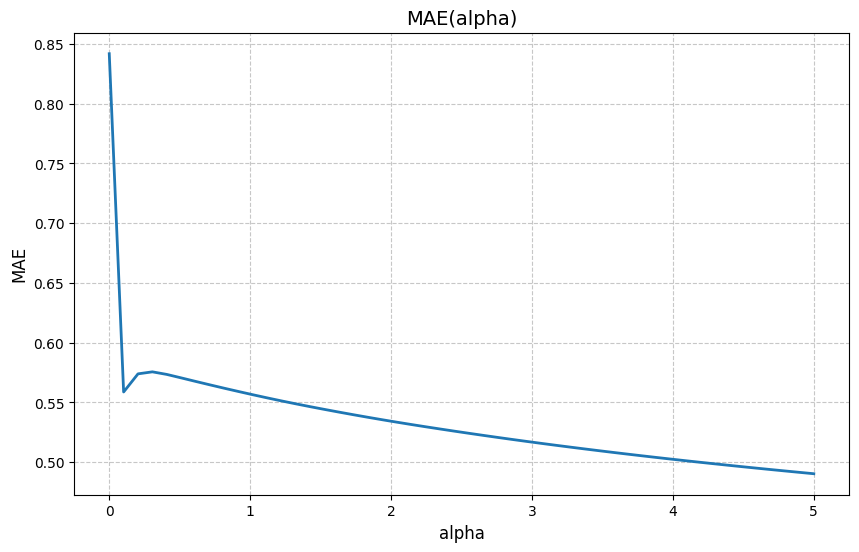

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(alpha_list, mae_list, linewidth=2)
plt.xlabel('alpha', fontsize=12)
plt.ylabel('MAE', fontsize=12)
plt.title('MAE(alpha)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Сейчас мы сделаем в некотором смысле немного глупое исследование, но тем не менее я хочу построить красивый график в $\mathbb{R}^3$:)

*очевидно при beta > 1 шаг будет быстро затухать, поэтому рассматриваем их маленькие

В процессе обучения возникли нюансы при маленьких значениях beta и больших alpha (MAE полетел в бесконечность), поэтому было принято стратегическое решение ограничить alpha сверху единицей.

In [13]:
alpha_list = np.linspace(1e-03, 1, 40)
beta_list = np.linspace(1e-02, 1, 40)
mae_matrix = np.zeros((len(alpha_list), len(beta_list)))

for i, alpha in enumerate(alpha_list):
    for j, beta in enumerate(beta_list):
        linear_model_ab = LinearModel(loss_function=loss_function,
                                step_alpha=alpha,
                                step_beta=beta,
                                max_iter=1500,
                                tolerance=1e-07)
        linear_model_ab.fit(X_train, y_train, trace=False)
        current_mae = mean_absolute_error(y_val, linear_model_ab.predict(X_val))
        mae_matrix[i, j] = current_mae
        print(f"alpha: {alpha:.5f}, beta: {beta:.5f}, MAE: {current_mae:.5f}")

alpha: 0.00100, beta: 0.01000, MAE: 0.57186
alpha: 0.00100, beta: 0.03538, MAE: 0.56914
alpha: 0.00100, beta: 0.06077, MAE: 0.56561
alpha: 0.00100, beta: 0.08615, MAE: 0.56143
alpha: 0.00100, beta: 0.11154, MAE: 0.55786
alpha: 0.00100, beta: 0.13692, MAE: 0.56118
alpha: 0.00100, beta: 0.16231, MAE: 0.56627
alpha: 0.00100, beta: 0.18769, MAE: 0.57352
alpha: 0.00100, beta: 0.21308, MAE: 0.58319
alpha: 0.00100, beta: 0.23846, MAE: 0.59540
alpha: 0.00100, beta: 0.26385, MAE: 0.60975
alpha: 0.00100, beta: 0.28923, MAE: 0.62572
alpha: 0.00100, beta: 0.31462, MAE: 0.64273
alpha: 0.00100, beta: 0.34000, MAE: 0.66015
alpha: 0.00100, beta: 0.36538, MAE: 0.67749
alpha: 0.00100, beta: 0.39077, MAE: 0.69445
alpha: 0.00100, beta: 0.41615, MAE: 0.71051
alpha: 0.00100, beta: 0.44154, MAE: 0.72547
alpha: 0.00100, beta: 0.46692, MAE: 0.73929
alpha: 0.00100, beta: 0.49231, MAE: 0.75190
alpha: 0.00100, beta: 0.51769, MAE: 0.76325
alpha: 0.00100, beta: 0.54308, MAE: 0.77338
alpha: 0.00100, beta: 0.56846, M

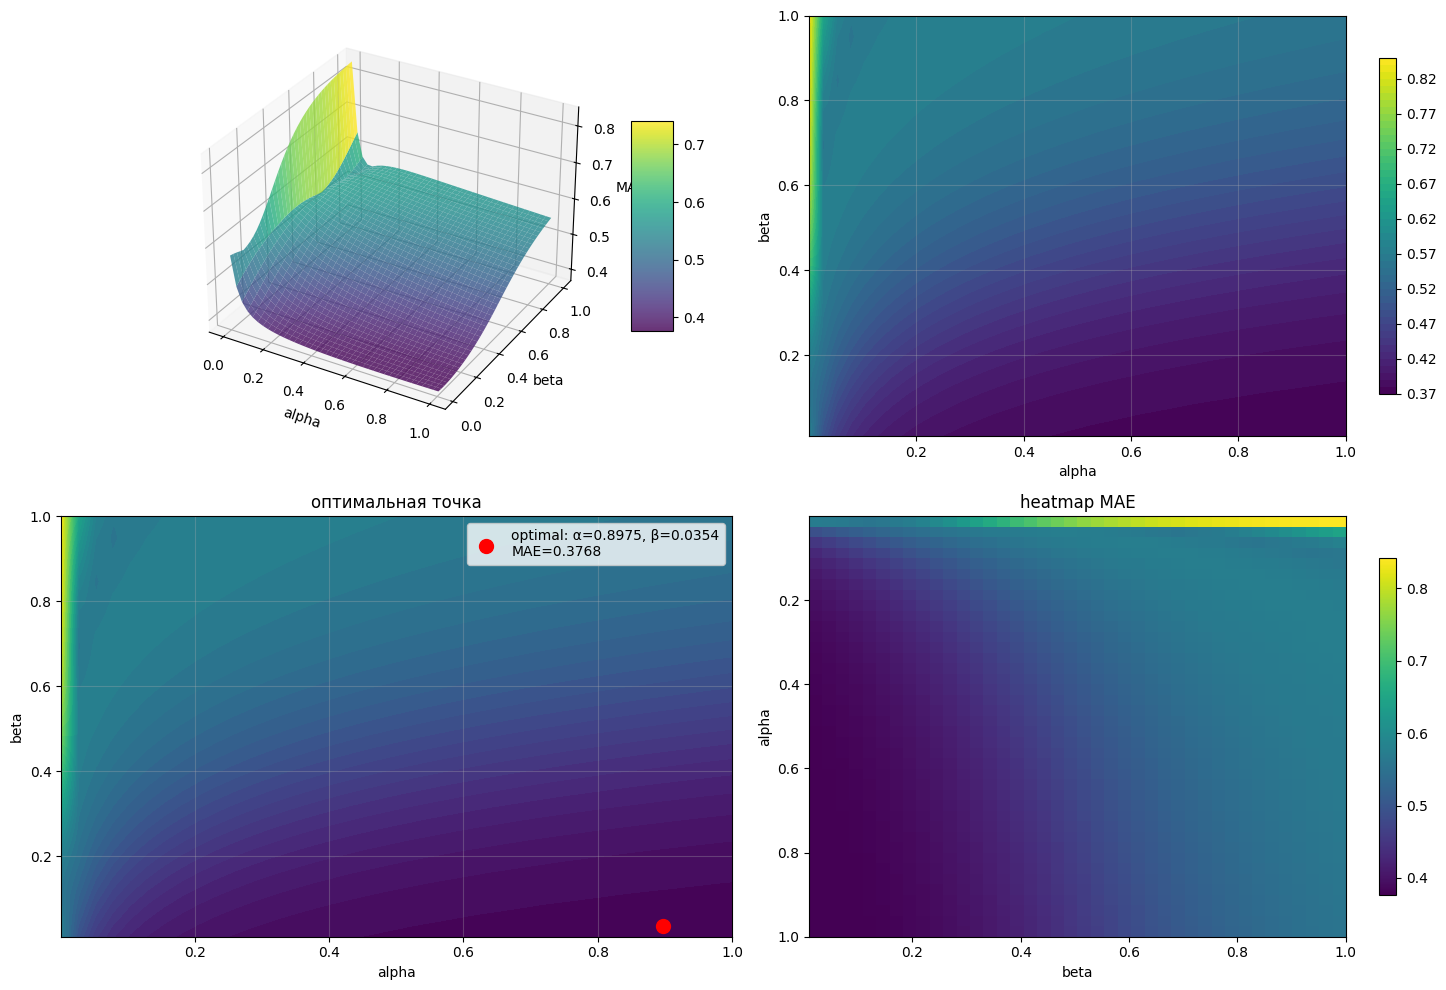


=== <Оптимальные> параметры ===
Лучший alpha: 0.8975
Лучший beta: 0.0354
Минимальный MAE: 0.3768

=== АНАЛИЗ СХОДИМОСТИ ДЛЯ ОПТИМАЛЬНЫХ ПАРАМЕТРОВ ===
Финальный MAE с оптимальными параметрами: 0.3768


In [14]:
Alpha, Beta = np.meshgrid(alpha_list, beta_list, indexing='ij')

fig = plt.figure(figsize=(15, 10))

ax1 = fig.add_subplot(2, 2, 1, projection='3d')
surf = ax1.plot_surface(Alpha, Beta, mae_matrix, cmap='viridis',
                       alpha=0.8, linewidth=0, antialiased=True)
ax1.set_xlabel('alpha')
ax1.set_ylabel('beta')
ax1.set_zlabel('MAE')
fig.colorbar(surf, ax=ax1, shrink=0.5, aspect=5)

ax2 = fig.add_subplot(2, 2, 2)
contour = ax2.contourf(Alpha, Beta, mae_matrix, levels=50, cmap='viridis')
ax2.set_xlabel('alpha')
ax2.set_ylabel('beta')
ax2.grid(True, alpha=0.3)
fig.colorbar(contour, ax=ax2, shrink=0.8)

min_idx = np.unravel_index(np.argmin(mae_matrix), mae_matrix.shape)
best_alpha = alpha_list[min_idx[0]]
best_beta = beta_list[min_idx[1]]
best_mae = mae_matrix[min_idx]

ax3 = fig.add_subplot(2, 2, 3)
contour3 = ax3.contourf(Alpha, Beta, mae_matrix, levels=50, cmap='viridis')
ax3.scatter(best_alpha, best_beta, color='red', s=100,
           label=f'optimal: α={best_alpha:.4f}, β={best_beta:.4f}\nMAE={best_mae:.4f}')
ax3.set_xlabel('alpha')
ax3.set_ylabel('beta')
ax3.set_title('оптимальная точка')
ax3.legend()
ax3.grid(True, alpha=0.3)

ax4 = fig.add_subplot(2, 2, 4)
im = ax4.imshow(mae_matrix, extent=[beta_list[0], beta_list[-1], alpha_list[-1], alpha_list[0]],
               aspect='auto', cmap='viridis')
ax4.set_xlabel('beta')
ax4.set_ylabel('alpha')
ax4.set_title('heatmap MAE')
fig.colorbar(im, ax=ax4, shrink=0.8)

plt.tight_layout()
plt.show()

print(f"\n=== <Оптимальные> параметры ===")
print(f"Лучший alpha: {best_alpha:.4f}")
print(f"Лучший beta: {best_beta:.4f}")
print(f"Минимальный MAE: {best_mae:.4f}")

print(f"\n=== АНАЛИЗ СХОДИМОСТИ ДЛЯ ОПТИМАЛЬНЫХ ПАРАМЕТРОВ ===")
optimal_model = LinearModel(loss_function=loss_function,
                          step_alpha=best_alpha,
                          step_beta=best_beta,
                          max_iter=1500,
                          tolerance=1e-07)
optimal_history = optimal_model.fit(X_train, y_train, trace=True)
final_mae = mean_absolute_error(y_val, optimal_model.predict(X_val))
print(f"Финальный MAE с оптимальными параметрами: {final_mae:.4f}")

Далее проведем небольшое и в каком-то смысле немного читерское исследование с помощью optuna (однако оно было указано в материалах, а значит разрешено к использованию), а, резюмируя все выше, я считаю, наиболее оптимальные диапазоны для поиска:
$$l2\_coef \in (1e-06, 1e-02),$$
так как большая регуляризация – плохо;
$$\alpha \in (0.6, 1.5),$$
$$\beta \in (1e-02, 1),$$
так как если будет больше этого, то будет слишком быстрое затухание.

In [15]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.9/400.9 kB 7.2 MB/s eta 0:00:00


In [18]:
import optuna

def objective(trial, X_train, y_train, X_val, y_val, random_seed=153):
    N_train = X_train.shape[0]

    l2_coef = trial.suggest_float("l2_coef", 1e-06, 1e-02, log=True)

    step_alpha = trial.suggest_float("step_alpha", 0.6, 1.5, log=True)

    step_beta = trial.suggest_float("step_beta", 1e-02, 1, log=True)

    max_bs = max(1, min(N_train, 1024))
    batch_size = None

    seed = random_seed

    loss = LinearLoss(l2_coef=l2_coef)
    model = LinearModel(
        loss_function=loss,
        step_alpha=step_alpha,
        step_beta=step_beta,
        tolerance=1e-07,
        max_iter=1000,
        random_seed=seed
    )

    history = model.fit(X_train, y_train, trace=False)

    y_pred = model.predict(X_val)
    y_true = np.asarray(y_val).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)

    if not np.all(np.isfinite(y_pred)):
        return 1e6

    score = mean_absolute_error(y_true, y_pred)

    return score


def run_optuna_search(X_train, y_train, X_val, y_val, n_trials=50, random_seed=153):
    sampler = optuna.samplers.TPESampler(seed=random_seed)
    study = optuna.create_study(direction="minimize", sampler=sampler)
    func = lambda trial: objective(trial, X_train, y_train, X_val, y_val, random_seed=random_seed)
    study.optimize(func, n_trials=n_trials, show_progress_bar=True)

    print("Best trial:")
    print("  Value (best MAE):", study.best_value)
    print("  Params:")
    for k, v in study.best_trial.params.items():
        print(f"    {k}: {v}")

    best_params = study.best_trial.params
    best_l2 = best_params["l2_coef"]
    best_step_alpha = best_params["step_alpha"]
    best_step_beta = best_params["step_beta"]

    final_loss = LinearLoss(l2_coef=best_l2)
    final_model = LinearModel(
        loss_function=final_loss,
        step_alpha=best_step_alpha,
        step_beta=best_step_beta,
        tolerance=1e-07,
        max_iter=1000,
        random_seed=random_seed
    )
    final_model.fit(X_train, y_train, trace=False)
    y_val_pred = final_model.predict(X_val)
    final_mae = mean_absolute_error(np.asarray(y_val).reshape(-1), np.asarray(y_val_pred).reshape(-1))
    print("Final MAE on validation with best params:", final_mae)

    return study, final_model

In [19]:
study, best_model = run_optuna_search(X_train, y_train, X_val, y_val, n_trials=120)

[I 2025-10-25 16:49:09,922] A new study created in memory with name: no-name-c4534a03-2951-4e32-b6fb-8d2749b6ef7e


  0%|          | 0/120 [00:00<?, ?it/s]

[I 2025-10-25 16:49:14,811] Trial 0 finished with value: 0.38167672761648497 and parameters: {'l2_coef': 3.8976192510450565e-06, 'step_alpha': 0.9743946617596927, 'step_beta': 0.09712683502603668}. Best is trial 0 with value: 0.38167672761648497.
[I 2025-10-25 16:49:18,199] Trial 1 finished with value: 0.4398082700654175 and parameters: {'l2_coef': 1.666201724910037e-06, 'step_alpha': 0.9454572921824351, 'step_beta': 0.4121427320311826}. Best is trial 0 with value: 0.38167672761648497.
[I 2025-10-25 16:49:21,505] Trial 2 finished with value: 0.3833183912879729 and parameters: {'l2_coef': 7.632790512100895e-06, 'step_alpha': 0.944896760535386, 'step_beta': 0.10997510452958206}. Best is trial 0 with value: 0.38167672761648497.
[I 2025-10-25 16:49:25,145] Trial 3 finished with value: 0.3866749375674187 and parameters: {'l2_coef': 1.3294272338893353e-05, 'step_alpha': 1.209236951151899, 'step_beta': 0.18473251006662186}. Best is trial 0 with value: 0.38167672761648497.
[I 2025-10-25 16:49:

Итак, лучший полученный $\text{MAE} \approx 0.376$

**5.** (3 points)
- Исследуйте поведение стохастического градиентного спуска для задачи линейной регрессии в зависимости от следующих параметров:
  - параметр темпа обучения ``step_alpha``
  - параметр темпа обучения ``step_beta``
  - размер подвыборки ``batch_size``

Замечание. Обратите внимание, что в стохастическом случае необходимо строить зависимости метрик качества от эпохи метода. За одну эпоху через оптимизацию модели проходит $N$ объектов, где $N$ — длина обучающей выборки. Если вы реализуете семплирование согласно спецификации задания, то за одну эпоху каждый объект пройдёт через оптимизацию ровно один раз. В полном градиентном спуске одна эпоха метода соответствует одной итерации обучения.

***Дисклеймер:*** *это исследовательская часть задания, где вы сами решаете, как много экспериментов проводить, как ограничить пространство поиска и прочие параметры. Оценка качества экспериментов будет основана на субъективных ощущениях проверяющего. Таким образом моделируется реальное исследование, когда вы в большинстве случаев не можете оценить, в какой области находится достаточно хорошее решение и сколько потребуется экспериментов для его достижения.*

**6.** (2 point) Сравните поведение двух методов между собой, сделайте выводы. Сравните оптимальные ``step_alpha`` и ``step_beta`` для разных методов.

**7.** (1 point) Подберите по отложенной выборке коэффициент $l2$-регуляризации модели.

**8.** (2 points) Выберите лучший алгоритм для тестовой выборки. Проанализируйте ошибки алгоритма. Проанализируйте и укажите общие черты объектов, на которых были допущены ошибки.